# Naive Bayes Classifier -- Urdu News Article Classifier
**Project:** Multi-class classification of Urdu news into 5 categories  
**Dataset:** 1140 articles | Sources: Express, Geo, Jang  
**Categories:** Business, Entertainment, Science and Technology, Sports, World  

## 1. Imports and Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from urduhack import stop_words
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# -- Constants --
DATA_PATH = "../data/combined_file.csv"
MAX_FEATURES = 12000
TEST_SIZE = 0.2
RANDOM_STATE = 42

## 2. Data Loading and EDA

In [3]:
articles = pd.read_csv(DATA_PATH)
articles['content'] = articles['content'].astype(str)
articles['title'] = articles['title'].astype(str)

print(f"Dataset shape: {articles.shape}")
print(f"\nMissing values:\n{articles.isnull().sum()}")
print(f"\nCategory distribution:\n{articles['gold_label'].value_counts()}")
articles.head()

Dataset shape: (1193, 5)

Missing values:
id            0
title         0
link          0
content       0
gold_label    0
dtype: int64

Category distribution:
gold_label
science-technology    240
world                 240
entertainment         239
sports                238
business              236
Name: count, dtype: int64


,id,title,link,content,gold_label
0,0,سلمان کے بعد شاہ رخ خان کو بھی جان سے مارنےکی ...,https://urdu.geo.tv/latest/385991-,ممبئی: بالی وڈ اداکار سلمان خان کے بعد اب کنگ...,entertainment
1,1,طلاق کی خبروں کے باوجود ابھیشیک اور ایشوریا کو...,https://urdu.geo.tv/latest/385972-,بالی وڈ کی معروف جوڑی ایشوریا رائے اور ابھیشیک...,entertainment
2,2,'میرا اپنا دماغ خراب تھا'، نادیہ خان نے کم عمر...,https://urdu.geo.tv/latest/385943-,پاکستان شوبز انڈسٹری کی معروف میزبان و اداکارہ...,entertainment
3,3,امیتابھ نہ شاہ رخ، بالی وڈ میں سب سے پہلے رولز...,https://urdu.geo.tv/latest/385850-,رولز رائس کا شمار لگژری اور مہنگی ترین گاڑیوں ...,entertainment
4,4,ہنی سنگھ کی پاکستانی گلوکار کو کریڈٹ دیکر سرا...,https://urdu.geo.tv/latest/385820-,بالی وڈ میں پاکستانی گانوں کو ہمیشہ ہی پسند کی...,entertainment


Content length stats:
count    1193.000000
mean     1047.906119
std       648.458299
min         3.000000
25%       668.000000
50%       924.000000
75%      1246.000000
max      6395.000000
Name: content_length, dtype: float64


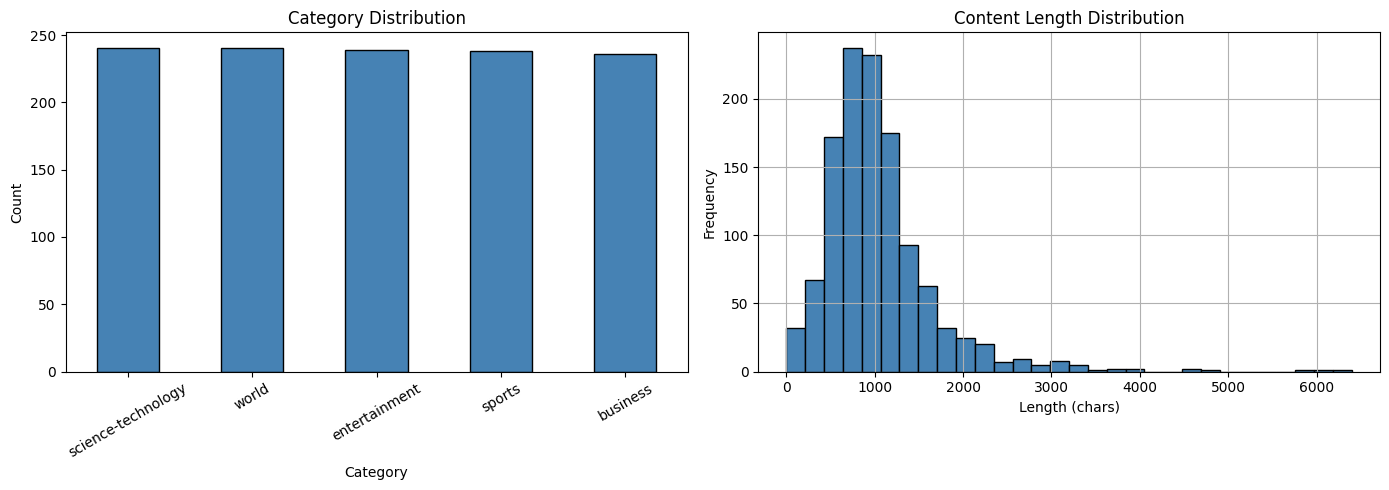

In [4]:
# -- Content Length Analysis --
articles['content_length'] = articles['content'].apply(len)

print(f"Content length stats:\n{articles['content_length'].describe()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

articles['gold_label'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Category Distribution')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

articles['content_length'].hist(bins=30, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Content Length Distribution')
axes[1].set_xlabel('Length (chars)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distribution.png', dpi=150)
plt.show()

## 3. Preprocessing

In [5]:
def clean_text(text: str) -> str:
    """Remove punctuation, digits, and Urdu stopwords."""
    stop_words_set = stop_words.STOP_WORDS
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    tokens = [w for w in text.split() if w not in stop_words_set]
    return " ".join(tokens)

articles['cleaned_content'] = articles['content'].apply(clean_text)
articles['cleaned_title'] = articles['title'].apply(clean_text)

print(articles[['title', 'cleaned_title', 'content', 'cleaned_content']].head())

                                               title  \
0  سلمان کے بعد شاہ رخ خان کو بھی جان سے مارنےکی ...   
1  طلاق کی خبروں کے باوجود ابھیشیک اور ایشوریا کو...   
2  'میرا اپنا دماغ خراب تھا'، نادیہ خان نے کم عمر...   
3  امیتابھ نہ شاہ رخ، بالی وڈ میں سب سے پہلے رولز...   
4  ہنی سنگھ کی پاکستانی گلوکار کو کریڈٹ دیکر  سرا...   

                                       cleaned_title  \
0                 سلمان شاہ رخ خان جان مارنےکی دھمکی   
1    طلاق خبروں ابھیشیک ایشوریا کونسی فلم جلوہ گر گے   
2                دماغ خراب نادیہ خان عمری شادی بتادی   
3                   امیتابھ شاہ رخ بالی وڈ رولز رائس   
4  ہنی سنگھ پاکستانی گلوکار کریڈٹ دیکر سرائیکی گا...   

                                             content  \
0  ممبئی: بالی وڈ اداکار سلمان خان کے بعد  اب کنگ...   
1  بالی وڈ کی معروف جوڑی ایشوریا رائے اور ابھیشیک...   
2  پاکستان شوبز انڈسٹری کی معروف میزبان و اداکارہ...   
3  رولز رائس کا شمار لگژری اور مہنگی ترین گاڑیوں ...   
4  بالی وڈ میں پاکستانی گانوں کو ہمیشہ ہی پسند

## 4. Vectorization and Train/Test Split

In [6]:
# Split raw text first to avoid data leakage
X_raw = articles['cleaned_content']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(articles['gold_label'])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Fit vectorizer only on training data
vectorizer = TfidfVectorizer(max_features=MAX_FEATURES)
X_train = vectorizer.fit_transform(X_train_raw).toarray()
X_test = vectorizer.transform(X_test_raw).toarray()

y_train = np.array(y_train)
y_test = np.array(y_test)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")

X_train: (954, 10756)  |  X_test: (239, 10756)
y_train: (954,)  |  y_test: (239,)


## 5. Naive Bayes -- From Scratch

Formula: `log P(c|x) = log P(c) + X * log P(x|c)`

- **A** stores word-frequency sums per class (TF-IDF weights).
- **Laplace smoothing** avoids zero-probability for unseen words.
- The prediction loop is vectorized for speed.

In [7]:
N_CLASSES = len(label_encoder.classes_)

# Build per-class word-frequency matrix
A = {}
for c in range(N_CLASSES):
    indices = np.where(y_train == c)[0]
    A[c] = X_train[indices].sum(axis=0)

print(f"Number of classes: {len(A)}")
print(f"Class labels: {label_encoder.classes_}")

Number of classes: 5
Class labels: ['business' 'entertainment' 'science-technology' 'sports' 'world']


In [8]:
# Compute priors P(c) and smoothed likelihoods P(word | class)
class_counts = np.array([len(np.where(y_train == c)[0]) for c in range(N_CLASSES)])
class_priors = class_counts / len(y_train)

A_smoothed = [A[c] + 1 for c in range(N_CLASSES)]       # Laplace smoothing
A_sums = [A_c.sum() for A_c in A_smoothed]
feature_probs = [A_smoothed[c] / A_sums[c] for c in range(N_CLASSES)]

In [9]:
def predict_naive_bayes(
    X: np.ndarray,
    class_priors: np.ndarray,
    feature_probs: list,
    n_classes: int = N_CLASSES,
) -> np.ndarray:
    """
    Predict class labels using vectorized log-probability Naive Bayes.

    Args:
        X             : (n_samples, n_features) dense TF-IDF array
        class_priors  : (n_classes,) array of P(c)
        feature_probs : list of (1, n_features) arrays P(word|class)
        n_classes     : number of target classes

    Returns:
        np.ndarray of predicted class indices
    """
    log_priors = np.log(class_priors)                              # (n_classes,)
    log_likelihoods = np.array(
        [np.log(feature_probs[c]) for c in range(n_classes)]
    ).squeeze()                                                    # (n_classes, n_features)

    # Vectorized: X @ log_likelihoods.T -> (n_samples, n_classes)
    scores = X @ log_likelihoods.T + log_priors
    return np.argmax(scores, axis=1)


y_pred = predict_naive_bayes(X_test, class_priors, feature_probs)

## 6. Evaluation

In [10]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(
    classification_report(
        y_test, y_pred, target_names=label_encoder.classes_
    )
)

Accuracy: 0.9331

Classification Report:
                    precision    recall  f1-score   support

          business       0.98      0.94      0.96        48
     entertainment       0.94      0.96      0.95        46
science-technology       0.97      0.85      0.91        46
            sports       0.96      0.98      0.97        48
             world       0.84      0.94      0.89        51

          accuracy                           0.93       239
         macro avg       0.94      0.93      0.93       239
      weighted avg       0.94      0.93      0.93       239



## 7. Confusion Matrix

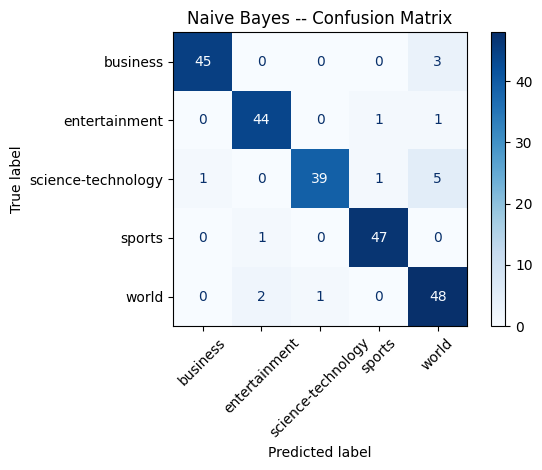

In [11]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=label_encoder.classes_,
    cmap='Blues',
    xticks_rotation=45,
)
plt.title("Naive Bayes -- Confusion Matrix")
plt.tight_layout()
plt.savefig("nb_confusion_matrix.png", dpi=150)
plt.show()

## 8. Benchmark Against sklearn MultinomialNB

In [13]:
from sklearn.naive_bayes import MultinomialNB

sklearn_nb = MultinomialNB()
sklearn_nb.fit(X_train, y_train)
sklearn_pred = sklearn_nb.predict(X_test)

print(f"Scratch NB Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Sklearn NB Accuracy : {accuracy_score(y_test, sklearn_pred):.4f}")

Scratch NB Accuracy : 0.9079
Sklearn NB Accuracy : 0.9079
